The base classes I used in the assignment 1 are left untouched.

## Basic classes

In [1]:
# Python standard libraries
import uuid     # Generally used for generating ids
import random   
import math     

In [2]:
class Position2D():
    '''Class used to keep track of 2D positions in cartesian coordinates'''
    def __init__(self, x: float, y: float):
        self.x = x      # X coordinate of the position
        self.y = y      # Y coordinate of the position

    def __add__(self, other: 'Position2D') -> 'Position2D':
        '''Add two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only add Position2D to Position2D")
        return Position2D(self.x + other.x, self.y + other.y)
    
    def __sub__(self, other: 'Position2D') -> 'Position2D':
        '''Subtract two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only subtract Position2D from Position2D")
        return Position2D(self.x - other.x, self.y - other.y)
    
    def __mul__(self, scalar: float) -> 'Position2D':
        '''Multiply the Position2D by a scalar'''
        if not isinstance(scalar, (int, float)):
            raise ValueError("Can only multiply Position2D by a scalar")
        return Position2D(self.x * scalar, self.y * scalar)
    
    def scale(self, scalar: float) -> None:
        '''Scale the Position2D by a scalar'''
        self.x = self.x * scalar
        self.y = self.y * scalar
    
    def randomNormalized(self) -> 'Position2D':
        '''Generate a random normalized Position2D'''
        angle = random.uniform(0, 2 * math.pi)
        return Position2D(math.cos(angle), math.sin(angle))

def distance_to(A: Position2D, B: Position2D) -> float:
    '''Calculate the Euclidean distance to another Position2D'''
    return ((A.x - B.x) ** 2 + (A.y - B.y) ** 2) ** 0.5

def direction_to(from_point: Position2D, to_point: Position2D) -> Position2D:
    '''Get normalized direction "Vector"'''
    point = to_point - from_point
    magnitude = distance_to(point, Position2D(0,0))
    return point * (1/magnitude)

### Abstract Agent, Task and Environment classes

In [3]:
from abc import ABC, abstractmethod
from asyncio import Task
from enum import Enum, auto

class Agent(ABC):
    '''Abstract base class for agents in a 2D environment'''
    def __init__(self, position: Position2D, task_radius: int, com_radius: int, velocity: int):
        # User parameters
        self._id = uuid.uuid4()                 # Unique identifier for the agent
        self.position = position                # Current position of the agent
        self.com_radius = com_radius            # Communication radius of the agent
        self.task_radius = task_radius          # Task radius of the agent
        self.velocity = velocity                # Velocity of the agent

        # Inner parameters
        self._state = AgentState.MOVING     # Needed for inner state machine
        self._sensorTask = None             # A readout of task signal
        self._sensorCom = None              # A readout of communication signal

    @abstractmethod
    def move(self):
        '''Move the agent to a new position'''
        pass
    
    @abstractmethod
    def writeTaskSensor(self, value: float, task) -> None:
        '''Function to pass information from the environment'''
        pass

    @abstractmethod
    def writeComSensor(self, agent: 'Agent', distance: float):
        '''Function to pass information from other agents in the environment'''
        pass

    @abstractmethod
    def decide(self) -> None:
        '''Should be called in every iteration -- bascially an implementation of agent behaviour'''
        pass
    
    @abstractmethod
    def taskComplete(self) -> None:
        '''Function to notify the agent that a task has been completed'''
        pass

class AgentState(Enum):
    '''Enumeration for agent states'''
    MOVING = auto()       # Agent is moving
    CALL_OUT = auto()     # Agent detected a task and should inform other agents
    WAITING = auto()      # Agent is waiting for a task to be completed
    RESPONDING = auto()   # Agent received a call-out/bid and tries to find the calling agent
    BIDDING = auto()      # Agent placed their bid
    AUCTIONER = auto()    # Agent resolves auction
    BRODCAST_AUCTION = auto()       # Agent starts auction

In [4]:
class AgentResponse(Enum):
    '''For communication between auctioner and bidder'''
    ACCEPT = auto()
    DECLINE = auto()
    WINNER = auto()
    LOSER = auto()

class AuctionAgent(ABC):
    '''Abstract base class for agents in a 2D environment'''
    def __init__(self, position: Position2D, task_radius: int, com_radius: int, velocity: int):
        # User parameters
        self._id = uuid.uuid4()                 # Unique identifier for the agent
        self.position = position                # Current position of the agent
        self.com_radius = com_radius            # Communication radius of the agent
        self.task_radius = task_radius          # Task radius of the agent
        self.velocity = velocity                # Velocity of the agent

        # Inner parameters
        self._state = AgentState.MOVING     # Needed for inner state machine
        self._sensorTask = None             # A readout of task signal
        self._sensorCom = None              # A readout of communication signal

    @abstractmethod
    def move(self):
        '''Move the agent to a new position'''
        pass
    
    @abstractmethod
    def writeTaskSensor(self, value: float, task) -> None:
        '''Function to pass information from the environment'''
        pass

    @abstractmethod
    def writeComSensor(self, agent: 'AuctionAgent', distance: float):
        '''Function to pass information from other agents in the environment'''
        pass

    @abstractmethod
    def decide(self) -> None:
        '''Should be called in every iteration -- bascially an implementation of agent behaviour'''
        pass

    @abstractmethod
    def make_bid(self, bidder: 'AuctionAgent', bid: float) -> None:
        '''Informes the auctioner that the agent wants to participate in the auction'''

    @abstractmethod
    def resolve_auction(self) -> None:
        '''Informes all the agents about the result of the auction'''

    @abstractmethod
    def resolve_bid(self, bid_result: AgentResponse, agent: 'AuctionAgent') -> AgentResponse:
        '''Used to finalize the bid, bidder responds to auctioner'''

    @abstractmethod
    def taskComplete(self) -> None:
        '''Function to notify the agent that a task has been completed'''
        pass

In [5]:
class Task():
    '''Class to represent a task in the environment'''
    def __init__(self, position: Position2D, capacity: int):
        self._id = uuid.uuid4()      # Unique identifier for the task
        self.position = position    # Position of the task in the environment
        self.agents = dict()        # Dict of agents currently in the task_radius = [agent._id] = agent_obj
        self.completed = False      # Boolean indicating if the task has been completed
        self.capacity = capacity    # Amount of agents needed to complete the task

    def add_agent(self, agent: Agent) -> None:
        '''Update the task status based on the number of agents in its radius'''
        self.agents[agent._id] = agent
        if len(self.agents) >= self.capacity:
            self.completed = True

    def remove_agent(self, agent: Agent) -> None:
        '''Remove an agent from the task's agent list'''
        self.agents.pop(agent._id, None)

    def agents_left(self) -> int:
        return self.capacity - len(self.agents)

    def clear_agents(self) -> None:
        self.agents = dict()
        
    def respawn(self, position: Position2D) -> None:
        '''Respawn the task at a new position'''
        self._id = uuid.uuid4()      # Regenerate UUID
        self.position = position
        self.agents = dict()
        self.completed = False

In [6]:
import random


class Environment():
    '''Class for managing agent environment'''
    def __init__(self, size: tuple[int, int], task_count: int, task_capacity: int, task_radius: int, agent_radius: int, agent_count: int, agent_class):
        
        # Environment parameters
        # =============================================================================================
        self.width = size[0]                        # Width of the rectangular 2D environment
        self.height = size[1]                       # Height of the rectangular 2D environment
        self._keepHistory = False                   # Whether to keep history of the environment state

        # Task parameters
        # =============================================================================================
        self.task_count = task_count                # Number of tasks in the environment
        self.task_capacity = task_capacity          # Amount of agents needed in task_radius to complete a task
        self.task_radius = task_radius              # Radius of each task's area of effect
        
        # Agent parameters
        # =============================================================================================
        self.agent_radius = agent_radius            # Radius of the agent communication area
        self.agent_count = agent_count              # Number of agents in the environment
        self.agent = agent_class                    # Class of agents in the environment - must be a subclass of Agent

        # Environment state
        # =============================================================================================
        self.tasks = dict()                                         # Dict of tasks in the environment [task._id] = task_obj
        self.agents = dict()                                        # Dict of agents in the environment [agent._id] = agent_obj
        self.tasks_done = dict()                                    # Keeps track of UUIDs of done tasks and agents UUIDs that completed them
        self.iteration = 0                                          # Current iteration of the environment
        self.history = {"agents": dict(), "tasks": dict()}          # History of the environment state (if needed)

    def initialize(self) -> None:
        '''Initialize the environment with tasks and agents'''

        # Reset agent and task dicts
        self.tasks = dict()
        self.agents = dict()

        # Create tasks
        for _ in range(self.task_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            task: Task = Task(Position2D(x, y), self.task_capacity)
            self.tasks[task._id] = task
        
        # Create agents
        for _ in range(self.agent_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            agent: Agent = self.agent(Position2D(x, y))
            self.agents[agent._id] = agent

        # Zero the counters        
        self.tasks_done = dict()
        self.history = {"agents": dict(), "tasks": dict()} 
        self._keepHistory = False
        self.iteration = 0

    def update_taskSensors(self) -> list:
        '''Updates readings of the task signals in agent sensors, returns a list of agents that are in the task radii and can communicate'''
        agentsList = dict()     # This will be used to narrow down the communication search later on

        # Clear the agents list
        for key in self.tasks:
            self.tasks[key].clear_agents()

        # Go through agents and check if they are near tasks
        for agentKey in self.agents:
            agent = self.agents[agentKey]
            for taskKey in self.tasks:
                task = self.tasks[taskKey]

                # Calculate distance
                dist = distance_to(agent.position, task.position)
                agent.writeTaskSensor(dist, task)

                if dist <= self.task_radius:
                    task.add_agent(agent)
                    if task._id not in agentsList:
                        agentsList[task._id] = list()
                    agentsList[task._id].append(agent._id)

        # Process tasks to check which of them are completed
        for taskKey in self.tasks:
            task = self.tasks[taskKey]
            
            if task.completed == False:
                continue

            
            # If the task is completed, we skip updating the sensor -- otherwise the agent might think it can still contribute
            self.tasks_done[task._id] = {"agents": list(task.agents.keys()), "iteration": self.iteration, "position": task.position}

            # Agents are no longer contributing as the task is closed
            agentsList.pop(task._id, None)

            for a_id in task.agents:
                a = task.agents[a_id]
                a.taskComplete()   # Notify agents that the task is complete

            task.respawn(Position2D(random.uniform(0, self.width), random.uniform(0, self.height)))    # Now new task needs to be spawned
            
            if self._keepHistory == True:
                if task._id not in self.history["tasks"]:
                    self.history["tasks"][task._id] = dict()
                self.history["tasks"][task._id]["position"] = task.position

        # Finally construct a list of agents
        agents = list()
        for taskKey in agentsList:
            for agent_id in agentsList[taskKey]:
                if agent_id not in agents:
                    agents.append(agent_id)

        return agents

    def update_communicationSensors(self, agentsList: list[Agent]) -> None:
        '''Updates readings of the communication signals in agent sensors'''
        for agentKey in agentsList:
            for otherKey in self.agents:
                agent = self.agents[agentKey]
                otherAgent = self.agents[otherKey]
                if agent._id == otherAgent._id:
                    # Skip self
                    continue
                
                # Communication only happens between agents that are in the com radius
                dist = distance_to(agent.position, otherAgent.position)
                if dist <= agent.com_radius:
                    if agent._state is AgentState.CALL_OUT or agent._state is AgentState.BRODCAST_AUCTION:
                        otherAgent.writeComSensor(agent, dist)
                        

    def run(self, iterations: int, keep_history: bool = False) -> None:
        '''Run the environment for a specified number of iterations'''
        self.initialize()

        # Prepare history
        self._keepHistory = keep_history
        if self._keepHistory == True:
            # Add tasks to history
            for taskKey in self.tasks:
                task = self.tasks[taskKey]
                self.history["tasks"][task._id] = dict()
                self.history["tasks"]["capacity"] = self.task_capacity
                self.history["tasks"]["radius"] = self.task_radius
                self.history["tasks"][task._id]['position'] = task.position

        for _ in range(iterations):
            # First we update sensors and tasks
            agentList = self.update_taskSensors()
            self.update_communicationSensors(agentList)

            # Then we let agents decide
            for agentKey in self.agents:
                agent = self.agents[agentKey]
                agent.decide()

                # Archive
                if self._keepHistory == True:
                    if agent._id not in self.history["agents"]:
                        self.history["agents"][agent._id] = dict()

                    if 'position' not in self.history["agents"][agent._id]:
                        self.history["agents"][agent._id]['position'] = list()
                    self.history["agents"][agent._id]['position'].append(agent.position)
                    self.history["agents"][agent._id]['state'] = agent._state.name

            self.iteration += 1
            

    def test_run(self):
        '''Run a simple test of the environment'''
        self.initialize()
        position =  [list(), list()]
        for _ in range(1000):
            self.iteration += 1
            #print(f"Iteration: {self.iteration}")
            for agent in self.agents:
                agent.move()
                position[0].append(agent.position.x)
                position[1].append(agent.position.y)
                #print(f"Agent {agent._id} moved to position ({agent.position.x}, {agent.position.y})")

        return position[0], position[1]

    def __repr__(self) -> str:
        return f"Environment(width={self.width}, height={self.height}, task_count={self.task_count}, task_capacity={self.task_capacity}, task_radius={self.task_radius}, agent_radius={self.agent_radius})"



### SimulatorRunner class
Class genereted by AI

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools # Used for systematically creating parameter combinations

class SimulationRunner:
    """
    A refactored, flexible helper class to manage running, analyzing, and 
    plotting simulation experiments using a generic sweep-and-plot approach.
    """
    def __init__(self, environment_class, agent_init_func, base_params: dict):
        self.environment_class = environment_class
        self.agent_init_func = agent_init_func
        self.base_params = base_params
        self.results = pd.DataFrame() # Results are now stored in a pandas DataFrame

    def _run_single_simulation(self, iterations: int, params: dict, seed: int) -> float:
        """(Internal) Runs one simulation and returns the performance score."""
        random.seed(seed)
        env = self.environment_class(
            size=params['ENV_SIZE'],
            task_count=params['task_count'],
            task_capacity=params['task_capacity'],
            task_radius=params['task_radius'],
            agent_radius=params['agent_radius'],
            agent_count=params['agent_count'],
            agent_class=lambda pos: self.agent_init_func(pos, params['velocity'], params)
        )
        env.run(iterations)
        return len(env.tasks_done) / iterations if iterations > 0 else 0

    # --------------------------------------------------------------------
    # CORE METHOD: A SINGLE, POWERFUL FUNCTION TO RUN ALL EXPERIMENTS
    # --------------------------------------------------------------------
    def run_sweep(self, sweep_params: dict, replications: int, description: str = "Running Sweep"):
        """
        Runs a generic parameter sweep for all combinations of given parameters.

        Args:
            sweep_params (dict): A dictionary where keys are parameter names and
                                 values are lists of values to test.
                                 e.g., {'agent_count': [5, 10], 'iterations': [1000, 2000]}
            replications (int): The number of times to run each unique parameter combination.
            description (str): A description for the progress bar.
        """
        print(f"--- Starting Parameter Sweep: {description} ---")
        
        # Generate all unique combinations of parameters
        param_names = list(sweep_params.keys())
        param_values = list(sweep_params.values())
        param_combinations = list(itertools.product(*param_values))
        
        all_results = []
        
        with tqdm(total=len(param_combinations) * replications, desc=description) as pbar:
            for combo in param_combinations:
                current_params = self.base_params.copy()
                
                # Create a dictionary for the current combination
                run_config = {}
                for i, name in enumerate(param_names):
                    current_params[name] = combo[i]
                    run_config[name] = combo[i]
                
                # Run the simulation 'replications' times for this combination
                for rep in range(replications):
                    score = self._run_single_simulation(current_params.get('iterations', 1), current_params, rep)
                    result_row = run_config.copy()
                    result_row['replication'] = rep
                    result_row['score'] = score
                    all_results.append(result_row)
                    pbar.update(1)

        self.results = pd.DataFrame(all_results)
        print("--- Sweep Finished ---")

    # --------------------------------------------------------------------
    # CORE METHOD: A SINGLE, POWERFUL FUNCTION TO PLOT ALL RESULTS
    # --------------------------------------------------------------------
    def plot(self, x_axis: str, series: str = None, title: str = None):
        """
        Generates a plot from the stored results.

        Args:
            x_axis (str): The name of the parameter to use for the x-axis.
            series (str, optional): The name of the parameter to use for creating
                                    different lines (series) on the plot. Defaults to None.
            title (str, optional): The title of the plot. Defaults to an auto-generated title.
        """
        if self.results.empty:
            print("No results to plot. Please run an experiment first.")
            return

        plt.figure(figsize=(12, 8))
        
        # Group by the series and x-axis parameters to calculate stats
        group_by_params = [series, x_axis] if series else [x_axis]
        stats = self.results.groupby(group_by_params)['score'].agg(['mean', 'std']).reset_index()

        if series:
            # Plot each series as a separate line with an error bar
            for name, group in stats.groupby(series):
                plt.errorbar(group[x_axis], group['mean'],
                             fmt='-o', capsize=5, label=f"{series.replace('_', ' ').title()} = {name}")
            plt.legend()
        else:
            # Plot a single line with an error bar
            plt.errorbar(stats[x_axis], stats['mean'], fmt='-o', capsize=5)

        # Formatting
        plt.xlabel(x_axis.replace('_', ' ').title())
        plt.ylabel("Average Score (Tasks / Iteration)")
        if not title:
            title = f"System Performance vs. {x_axis.replace('_', ' ').title()}"
            if series:
                title += f" by {series.replace('_', ' ').title()}"
        plt.title(title)
        plt.grid(True)
        plt.show()

    # --------------------------------------------------------------------
    # CONVENIENCE WRAPPERS (Old functions now call the core methods)
    # --------------------------------------------------------------------
    def run_experiment(self, parameter_to_vary: str, parameter_values: list, iterations: int, replications: int):
        """Convenience wrapper for a simple 1D parameter sweep."""
        sweep_params = {
            parameter_to_vary: parameter_values,
            'iterations': [iterations] # Iterations is fixed
        }
        self.run_sweep(sweep_params, replications, f"Varying '{parameter_to_vary}'")
        self.plot(x_axis=parameter_to_vary)

    def run_iteration_experiment(self, iteration_values: list, replications: int):
        """Convenience wrapper to see performance vs. simulation length."""
        sweep_params = {'iterations': iteration_values}
        self.run_sweep(sweep_params, replications, "Testing Iteration Lengths")
        self.plot(x_axis='iterations')

    def run_parameter_sweep_over_iterations(self, parameter_to_vary: str, parameter_values: list, iteration_values: list, replications: int):
        """Convenience wrapper for a 2D parameter sweep."""
        sweep_params = {
            parameter_to_vary: parameter_values,
            'iterations': iteration_values
        }
        self.run_sweep(sweep_params, replications, f"Sweeping '{parameter_to_vary}' vs. Iterations")
        self.plot(x_axis='iterations', series=parameter_to_vary)

    def visualize_single_run(self, iterations: int, vis_params: dict = None):
        """
        Runs a single simulation with history tracking and plots the agent trajectories.

        Args:
            iterations (int): The number of iterations to run the simulation for.
            vis_params (dict, optional): A dictionary of specific parameters for this run.
                                         If None, uses the runner's base_params.
        """
        print("--- Starting Single Run for Visualization ---")
        
        # Use specific parameters for this run, or the base ones if none are given
        if vis_params is None:
            vis_params = self.base_params
        
        # Create a dedicated environment for this visualization run
        env = self.environment_class(
            size=vis_params['ENV_SIZE'],
            task_count=vis_params['task_count'],
            task_capacity=vis_params['task_capacity'],
            task_radius=vis_params['task_radius'],
            agent_radius=vis_params['agent_radius'],
            agent_count=vis_params['agent_count'],
            agent_class=lambda pos: self.agent_init_func(pos, velocity=vis_params['velocity'])
        )
        
        # Run the simulation with history tracking enabled
        env.run(iterations, keep_history=True)
        print("--- Simulation Finished, Generating Plot ---")

        # --- Plotting Logic (from your provided code) ---
        plt.figure(figsize=(10, 10))
        
        # Plot agent trajectories from env.history
        for agent_id, agent_hist in env.history["agents"].items():
            if 'position' in agent_hist:
                x = [pos.x for pos in agent_hist['position']]
                y = [pos.y for pos in agent_hist['position']]
                plt.plot(x, y, label=f'Agent {str(agent_id)[:8]}', alpha=0.8)

        # Plot task positions and radii from env.history
        # This will plot both the initial and all respawned task locations
        task_radius_val = env.task_radius # Use the definitive value from the env
        plotted_task_labels = set()

        for task_id, task_hist in env.history["tasks"].items():
            if isinstance(task_hist, dict) and 'position' in task_hist:
                pos = task_hist['position']
                label = f'Task Location'
                if label not in plotted_task_labels:
                    plt.scatter(pos.x, pos.y, c='red', marker='*', s=200, label=label)
                    plotted_task_labels.add(label)
                else:
                    plt.scatter(pos.x, pos.y, c='red', marker='*', s=200)
                
                # Draw task radius as a circle
                circle = plt.Circle((pos.x, pos.y), task_radius_val, color='red', fill=False, linestyle='--', alpha=0.4)
                plt.gca().add_patch(circle)

        plt.xlabel('X position')
        plt.ylabel('Y position')
        plt.title(f'Agent Trajectories and Task Locations ({iterations} Iterations)')
        
        # To avoid clutter, only show a limited number of agent labels in the legend
        handles, labels = plt.gca().get_legend_handles_labels()
        # Display task labels + up to 5 agent labels
        plt.legend(handles[:6], labels[:6])
        
        plt.grid(True)
        plt.axis('equal')
        plt.xlim(0, vis_params['ENV_SIZE'][0])
        plt.ylim(0, vis_params['ENV_SIZE'][1])
        plt.show()

The agent that will be compared against is the one with call-out ability -- I feel like it's a fair comparison as the auction mechanism can be interpreted as "more intelligent" call-out

In [8]:
class SocialAgent(Agent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, env_size: tuple[int, int], task_radius:int, com_radius: int, timeout_callout:int, timeout_respond: int, velocity: int):
        super().__init__(position, task_radius, com_radius, velocity)
        self.timeout_callout = timeout_callout      # How many iterations the agent should wait for help
        self.timeout_respond = timeout_respond      # How many iterations the agent should try to find callout caller
        self._boundary = env_size

        self._direction = Position2D(0,0)
        self._lastDistance = None
        self._waitingTime = 0                   # How long the agent has been waiting in the waiting state
        self._respondTime = 0                   # How long the agent has been trying to respond to callout

    def move(self):
        '''Move the agent to a new position -- perform random walk'''
        velocity_vector = Position2D(0, 0).randomNormalized()   
        velocity_vector.scale(self.velocity)
        new_position = self.position + velocity_vector 

        # Check for boundary collisions
        if 0 <= new_position.x <= self._boundary[0] and 0 <= new_position.y <= self._boundary[1]:
            self.position = new_position
        else:
            # If out of bounds then agent should:
            # 1. Move to the boundary
            # 2. "Reroll" movement 
            # 3. Go rest of the distance within bounds
            first_scale = 1.0
            dist_x, dist_y = 0, 0

            # The movement after the boundary hit
            second_movement = Position2D(0, 0).randomNormalized()
            second_movement.scale(self.velocity)    # So this operation isn't forgotten along the way

            # First it is needed to check which boundary is hit, and how much distance is left to it
            # At the same time the second_movement will be modified so it won't be out of bounds -- this behaviour can be imagined as turning 180 and picking some new angle from <-90, 90>
            
            # Even though for simplification, the check is done by assuming that the agent knows where it is in real implementation it would not be necessary,
            # In reality it would be enough to give the robotic agent cheap sensor such as ultrasound sensor and set some tresholding 
            # So in this implementation it is assumed that the dist_x, dist_y can be yielded from sensor outputs
            if new_position.x < 0:
                dist_x = -self.position.x
                second_movement.x = abs(second_movement.x)
            elif new_position.x > self._boundary[0]:
                dist_x = self._boundary[0] - self.position.x
                second_movement.x = -abs(second_movement.x)
            elif new_position.y < 0:
                dist_y = -self.position.y
                second_movement.y = abs(second_movement.y)
            elif new_position.y > self._boundary[1]:
                dist_y = self._boundary[1] - self.position.y
                second_movement.y = -abs(second_movement.y)
            
            # Now the movement should be capped to the closest boundary
            if abs(dist_x) >= abs(dist_y):
                first_scale = abs(dist_y / velocity_vector.y) if velocity_vector.y != 0 else 0
            else:
                first_scale = abs(dist_x / velocity_vector.x) if velocity_vector.x != 0 else 0
            
            # Rescale
            velocity_vector.scale(first_scale)
            second_movement.scale(1.0 - first_scale)

            # Final position
            self.position = self.position + velocity_vector + second_movement

    def moveDirection(self):
        '''Moves toward agent that called out'''

        new_position = self.position + self._direction * self.velocity

        # Check for boundaries -- if the agent will try to move outside it means that probably it missed the callout.
        # For simplicity it doesn't bounce back just stops
        stop = True
        if new_position.x < 0:
            new_position.x = 0
        elif new_position.x > self._boundary[0]:
            new_position.x = self._boundary[0]
        elif new_position.y < 0:
            new_position.y = 0
        elif new_position.y > self._boundary[1]:
            new_position.y = self._boundary[1]

        else:
            # If it didnt cross any boundary we are good
            stop = False

        self.position = new_position
        self._respondTime += 1

        # The agent and task was not found
        if stop == True:
            self._state = AgentState.MOVING
            self._respondTime = 0
        

    def decide(self):
        '''Update the agent's state and perform actions based on its state'''
        # This agent doesn't communicate with other agents and has four states -- waiting, moving and responding
        
        # First check if the agent is still waiting for task to complete
        if self._state is AgentState.WAITING:
            # If the agent has been waiting for too long, it goes back to moving
            if self._waitingTime >= self.timeout_callout:
                self._state = AgentState.MOVING
                self._waitingTime = 0

            self._waitingTime += 1
            return
        elif self._state is AgentState.CALL_OUT:
            # Switch to waiting state
            self._state = AgentState.WAITING
            self._waitingTime = 0

        elif self._state is AgentState.MOVING:
            # First check if it is in task radius
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.CALL_OUT
                return
            
            # Then we check if other agent tried to reach us
            if self._lastDistance is not None:
                self._state = AgentState.RESPONDING
                self._respondTime = 0
                self._lastDistance = None

                # In this scenario the agent should try to move in the direction of the callout
                self.moveDirection()
                return

            self.move()

        elif self._state is AgentState.RESPONDING:
            self._lastDistance = None
            # Check if the agent should still move
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.CALL_OUT
        
            elif self._respondTime >= self.timeout_respond:
                self._state = AgentState.MOVING
                self.move()
            
            else: self.moveDirection()

        else:
            raise ValueError(f"Agent {0} is in illegal state: {1}", self._id, self._state)
        
    def writeComSensor(self, agent: Agent, distance: float) -> None:
        '''Receives communication signal from other Agent'''
        # Write into only if the agent is closer or its the first agent to call
        if self._state is not AgentState.MOVING:
            return 
        
        # Respond to the closest agent
        if self._lastDistance is None or distance < self._lastDistance:
            self._lastDistance = distance
            self._direction = direction_to(self.position, agent.position)
            

    def writeTaskSensor(self, value: float, task: Task) -> None:
        self._sensorTask = value
        # This agent is simple enough not to store data about the task

    def taskComplete(self) -> None:
        '''Notify the agent that the task it was working on has been completed'''
        self._state = AgentState.MOVING
        self._respondTime = 0
        self._waitingTime = 0
        


# Agents with Auction mechanism

As the task is to enhance the previous agents with auction mechanism, I want to preface the implementation with justification. 

First the assumptions:
- the agents always place bids without over/under estimation -- this means that any mechanisms preventing strategic manipulation are not needed
- the problem falls under combinatorial auctions -- the auctioner goal could be interpreted as hiring the most qualified team
- smaller bids = better bids -- the problem will be interpreted as minimizng the effort (cost/bid), of course this can be translated easily into maximalization problem by setting bid value as $\frac{1}{distance}$ but it inposes numerical stability so I won't do it.

Now there is non-zero chance that the agent will win more that one auction, I imagine two feasible solutions:
- agent accepts first auction bid that it wins -- simple mechanics can lead to less optimal solutions
- agent accepts auction that requires less effort (shortest distance) -- in this scenario I imagine that the auction lasts as long as the 'full' package of winners is assembled by the auctioner, each win needs to be accepted by the bidder as confirmation that it will follow through

## Implementation

In [9]:

class SimpleAuctionAgent(AuctionAgent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, env_size: tuple[int, int], task_radius:int, com_radius: int, timeout_callout:int, timeout_respond: int, velocity: int):
        super().__init__(position, task_radius, com_radius, velocity)
        self.timeout_callout = timeout_callout      # How many iterations the agent should wait for help
        self.timeout_respond = timeout_respond      # How many iterations the agent should try to find callout caller
        self._boundary = env_size

        self._direction = Position2D(0,0)
        self._lastDistance = None
        self._waitingTime = 0                   # How long the agent has been waiting in the waiting state
        self._respondTime = 0                   # How long the agent has been trying to respond to callout/bid
        self._agentsLeft = 0                    # How many more agents are needed for the current task
        self._wonBid = False                    # Flag to save the current status of the bidding
        self._receivedResponse = False          # Flag to make sure that the agent received the response 
        self._bids = dict()                     # Agents that placed their bids {agent: bid}

    def move(self):
        '''Move the agent to a new position -- perform random walk'''
        velocity_vector = Position2D(0, 0).randomNormalized()   
        velocity_vector.scale(self.velocity)
        new_position = self.position + velocity_vector 

        # Check for boundary collisions
        if 0 <= new_position.x <= self._boundary[0] and 0 <= new_position.y <= self._boundary[1]:
            self.position = new_position
        else:
            # If out of bounds then agent should:
            # 1. Move to the boundary
            # 2. "Reroll" movement 
            # 3. Go rest of the distance within bounds
            first_scale = 1.0
            dist_x, dist_y = 0, 0

            # The movement after the boundary hit
            second_movement = Position2D(0, 0).randomNormalized()
            second_movement.scale(self.velocity)    # So this operation isn't forgotten along the way

            # First it is needed to check which boundary is hit, and how much distance is left to it
            # At the same time the second_movement will be modified so it won't be out of bounds -- this behaviour can be imagined as turning 180 and picking some new angle from <-90, 90>
            
            # Even though for simplification, the check is done by assuming that the agent knows where it is in real implementation it would not be necessary,
            # In reality it would be enough to give the robotic agent cheap sensor such as ultrasound sensor and set some tresholding 
            # So in this implementation it is assumed that the dist_x, dist_y can be yielded from sensor outputs
            if new_position.x < 0:
                dist_x = -self.position.x
                second_movement.x = abs(second_movement.x)
            elif new_position.x > self._boundary[0]:
                dist_x = self._boundary[0] - self.position.x
                second_movement.x = -abs(second_movement.x)
            elif new_position.y < 0:
                dist_y = -self.position.y
                second_movement.y = abs(second_movement.y)
            elif new_position.y > self._boundary[1]:
                dist_y = self._boundary[1] - self.position.y
                second_movement.y = -abs(second_movement.y)
            
            # Now the movement should be capped to the closest boundary
            if abs(dist_x) >= abs(dist_y):
                first_scale = abs(dist_y / velocity_vector.y) if velocity_vector.y != 0 else 0
            else:
                first_scale = abs(dist_x / velocity_vector.x) if velocity_vector.x != 0 else 0
            
            # Rescale
            velocity_vector.scale(first_scale)
            second_movement.scale(1.0 - first_scale)

            # Final position
            self.position = self.position + velocity_vector + second_movement

    def moveDirection(self):
        '''Moves toward agent that called out'''

        new_position = self.position + self._direction * self.velocity

        # Check for boundaries -- if the agent will try to move outside it means that probably it missed the callout.
        # For simplicity it doesn't bounce back just stops
        stop = True
        if new_position.x < 0:
            new_position.x = 0
        elif new_position.x > self._boundary[0]:
            new_position.x = self._boundary[0]
        elif new_position.y < 0:
            new_position.y = 0
        elif new_position.y > self._boundary[1]:
            new_position.y = self._boundary[1]

        else:
            # If it didnt cross any boundary we are good
            stop = False

        self.position = new_position
        self._respondTime += 1

        # The agent and task was not found
        if stop == True:
            self._state = AgentState.MOVING
            self._respondTime = 0
        

    def decide(self):
        '''Update the agent's state and perform actions based on its state'''
        # This agent doesn't communicate with other agents and has four states -- waiting, moving and responding
        
        # First check if the agent is still waiting for task to complete
        if self._state is AgentState.WAITING:
            # If the agent has been waiting for too long, it goes back to moving
            if self._waitingTime >= self.timeout_callout:
                self._state = AgentState.MOVING
                self._waitingTime = 0

            self._waitingTime += 1
            return
        
        elif self._state is AgentState.AUCTIONER:
            # Switch to waiting state
            self.resolve_auction()

            self._bids = dict()
            self._agentsLeft = 0 
            self._state = AgentState.WAITING
            self._waitingTime = 0

        elif self._state is AgentState.BRODCAST_AUCTION:
            # To make one turn offset
            self._state = AgentState.AUCTIONER
            return

        elif self._state is AgentState.MOVING:
            # First check if it is in task radius
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.BRODCAST_AUCTION
                return

            self.move()

        elif self._state is AgentState.BIDDING:
            # Check if agent got any response
            if self._receivedResponse == False:
                if self._respondTime > self.timeout_respond:
                    # Fallback if the bidding response didnt reach agent
                    self._respondTime = 0
                    self._state = AgentState.MOVING
                    self.move()

                else: 
                    self._respondTime += 1

                return 
            
            # Check if won the bid
            if self._receivedResponse:
                if self._wonBid:
                    self._state = AgentState.RESPONDING
                    self.moveDirection()
                    return 

            self._state = AgentState.MOVING
            self.move()

        elif self._state is AgentState.RESPONDING:
            # Check if the agent should still move
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.BRODCAST_AUCTION
        
            elif self._respondTime >= self.timeout_respond:
                self._state = AgentState.MOVING
                self.move()
            
            else: self.moveDirection()

        else:
            raise ValueError(f"Agent {0} is in illegal state: {1}", self._id, self._state)
        
    def writeComSensor(self, agent: AuctionAgent, distance: float):
        '''Receives communication signal from other Agent'''
        # The communication is interpreted as auction call
        if self._state is not AgentState.MOVING:
            # The agent has to be free-roaming to participate in auction
            return 
        
        # Save the new distance and movement direction
        self._lastDistance = distance
        self._direction = direction_to(self.position, agent.position)

        # Now the agent is bidding
        self._state  = AgentState.BIDDING
        self._wonBid = False
        self._receivedResponse = False
        agent.make_bid(self, distance)

    def make_bid(self, bidder, bid: float) -> None:
        if self._state is AgentState.BRODCAST_AUCTION:
            self._bids[bidder] = bid

    def resolve_auction(self) -> None:
        confirmed_bids = 0
        sorted_bidders = sorted(self._bids.items(), key=lambda item: item[1])

        # Sort from smaller to bigger distance
        for agent, value in sorted_bidders:
            # If there are still places to fill
            if confirmed_bids < self._agentsLeft:
                msg = agent.resolve_bid(AgentResponse.WINNER, self)

                # If bidder confirms assume it will follow through
                if msg == AgentResponse.ACCEPT:
                    confirmed_bids += 1
            
            else:
                agent.resolve_bid(AgentResponse.LOSER, self)

    def resolve_bid(self, bid_result: AgentResponse, agent: AuctionAgent) -> AgentResponse:
        # If in bidding state it means that the win message wasn't received
        if self._state is not AgentState.BIDDING or self._wonBid == True:
            return AgentResponse.DECLINE
        
        self._receivedResponse = True
        if bid_result == AgentResponse.WINNER:
            # Agent accepts the first won auction -- and proceedes to action
            self._direction = direction_to(self.position, agent.position)
            self._wonBid = True
            return AgentResponse.ACCEPT
        
        return AgentResponse.DECLINE


    def writeTaskSensor(self, value: float, task: Task) -> None:
        self._sensorTask = value
        self._agentsLeft = task.agents_left()

    def taskComplete(self) -> None:
        '''Notify the agent that the task it was working on has been completed'''
        self._state = AgentState.MOVING
        self._respondTime = 0
        self._waitingTime = 0
        


## Tests

--- Starting Parameter Sweep: Varying Communication Radius ---


Varying Communication Radius: 100%|██████████| 160/160 [02:14<00:00,  1.19it/s]

--- Sweep Finished ---


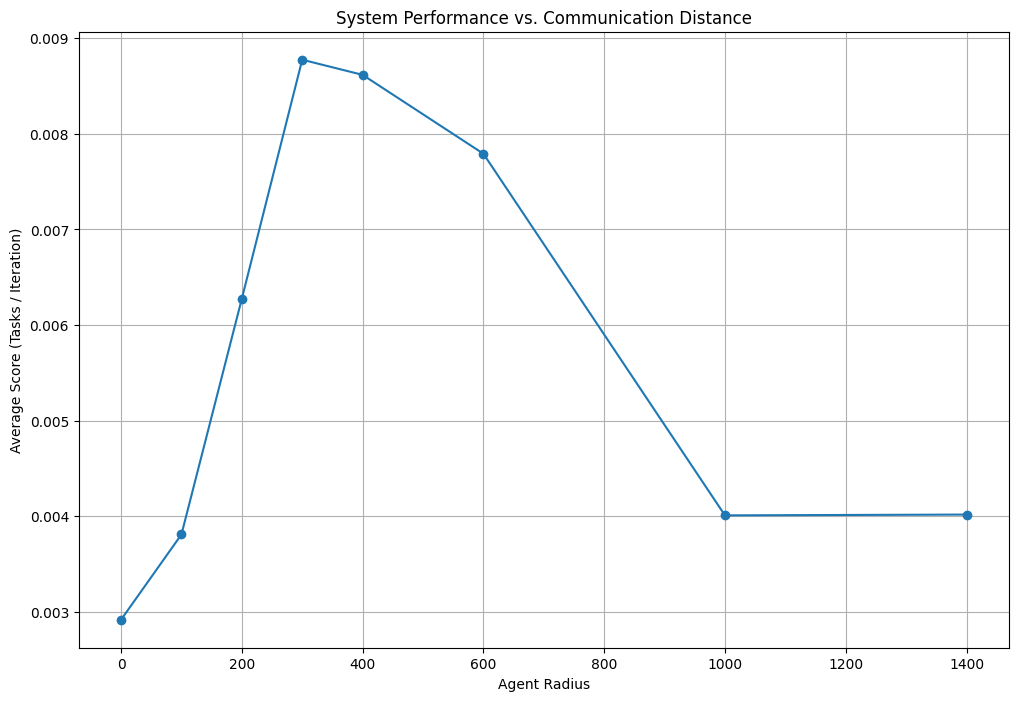

In [ ]:
social_base_params = {
    'ENV_SIZE': (1000, 1000),
    'task_count': 2,
    'task_capacity': 3,
    'task_radius': 30,
    'agent_radius': 250, # A default value we will sweep over
    'agent_count': 30,
    'velocity': 25,
    'timeout_callout': 200, # e.g., wait 200 iterations before giving up
    'timeout_respond': 250  # e.g., search for 250 iterations before giving up
}

# Step 2: Create a new agentInit function for the SocialAgent
def socialAgentInit(pos, velocity, params):
    # This function now pulls the timeout values from the params dictionary
    return SocialAgent(
        pos, 
        params['ENV_SIZE'], 
        params['task_radius'], 
        params['agent_radius'], 
        params['timeout_callout'],
        params['timeout_respond'],
        velocity
    )

# Step 3: Create a new SimulationRunner instance for this experiment
social_runner = SimulationRunner(Environment, socialAgentInit, social_base_params)

# Step 4: Define and run the experiment (e.g., for assignment question e)
# We will test performance vs. communication distance (agent_radius)
# Let's use a fixed number of iterations and replications for this test.
# You would ideally use your convergence analysis to find these numbers first.

sweep_parameters =  {
    'agent_radius': [600],
    'agent_count': [30],
    'task_capacity': [3, 5, 7, 10],
    'task_count': [2],
    'iterations': [4000] # Fixed simulation length
}

social_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=20, # A reasonable number of replications
    description="Varying Communication Radius"
)

# Step 5: Plot the results
social_runner.plot(
    x_axis='agent_radius',
    title="System Performance vs. Communication Distance"
)

--- Starting Parameter Sweep: Varying Communication Radius ---


Varying Communication Radius: 100%|██████████| 400/400 [05:32<00:00,  1.20it/s]

--- Sweep Finished ---


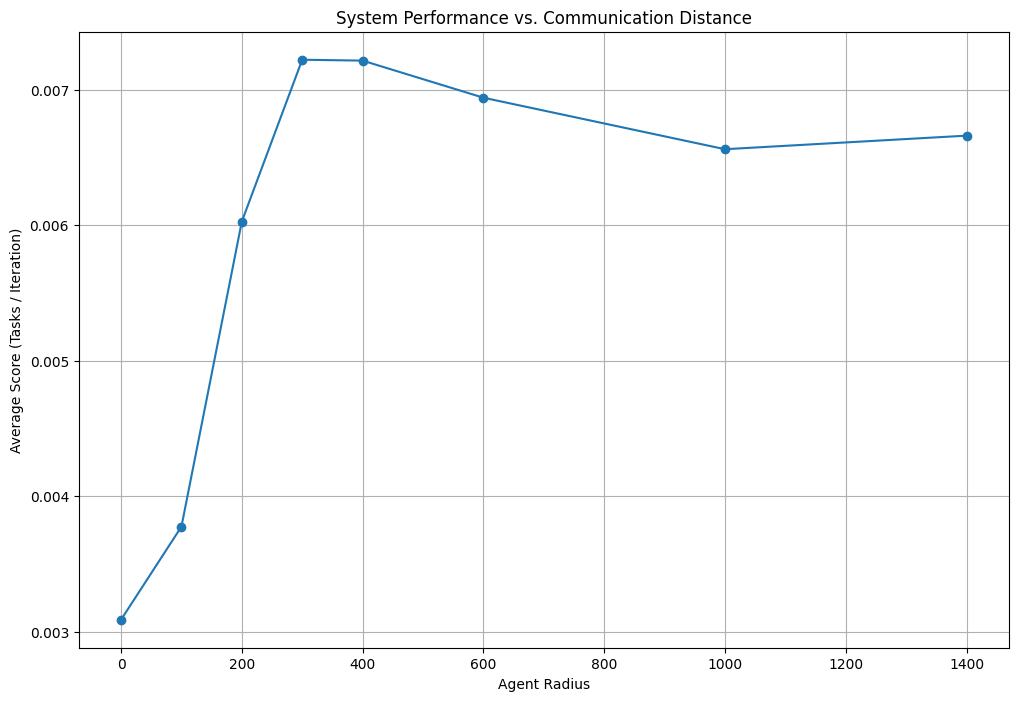

In [ ]:
auction_base_params = {
    'ENV_SIZE': (1000, 1000),
    'task_count': 2,
    'task_capacity': 3,
    'task_radius': 30,
    'agent_radius': 250, # A default value we will sweep over
    'agent_count': 30,
    'velocity': 25,
    'timeout_callout': 200, # e.g., wait 200 iterations before giving up
    'timeout_respond': 10  # e.g., search for 250 iterations before giving up
}

# Step 2: Create a new agentInit function for the SocialAgent
def auctionAgentInit(pos, velocity, params):
    # This function now pulls the timeout values from the params dictionary
    return SimpleAuctionAgent(
        pos, 
        params['ENV_SIZE'], 
        params['task_radius'], 
        params['agent_radius'], 
        params['timeout_callout'],
        params['timeout_respond'],
        velocity
    )

# Step 3: Create a new SimulationRunner instance for this experiment
auction_runner= SimulationRunner(Environment, auctionAgentInit, auction_base_params)

# Step 4: Define and run the experiment (e.g., for assignment question e)
# We will test performance vs. communication distance (agent_radius)
# Let's use a fixed number of iterations and replications for this test.
# You would ideally use your convergence analysis to find these numbers first.

sweep_parameters = {
    'agent_radius': [600],
    'agent_count': [30],
    'task_capacity': [3, 5, 7, 10],
    'task_count': [2],
    'iterations': [4000] # Fixed simulation length
}

auction_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=50, # A reasonable number of replications
    description="Varying Communication Radius"
)

# Step 5: Plot the results
auction_runner.plot(
    x_axis='agent_radius',
    title="System Performance vs. Communication Distance"
)

--- Starting Parameter Sweep: Reactive Agent (Social) ---


Reactive Agent (Social): 100%|██████████| 160/160 [01:39<00:00,  1.61it/s]


--- Sweep Finished ---
--- Starting Parameter Sweep: Interactive Agent (Auction) ---


Interactive Agent (Auction): 100%|██████████| 160/160 [01:49<00:00,  1.46it/s]


--- Sweep Finished ---

--- Generating Final Plot ---


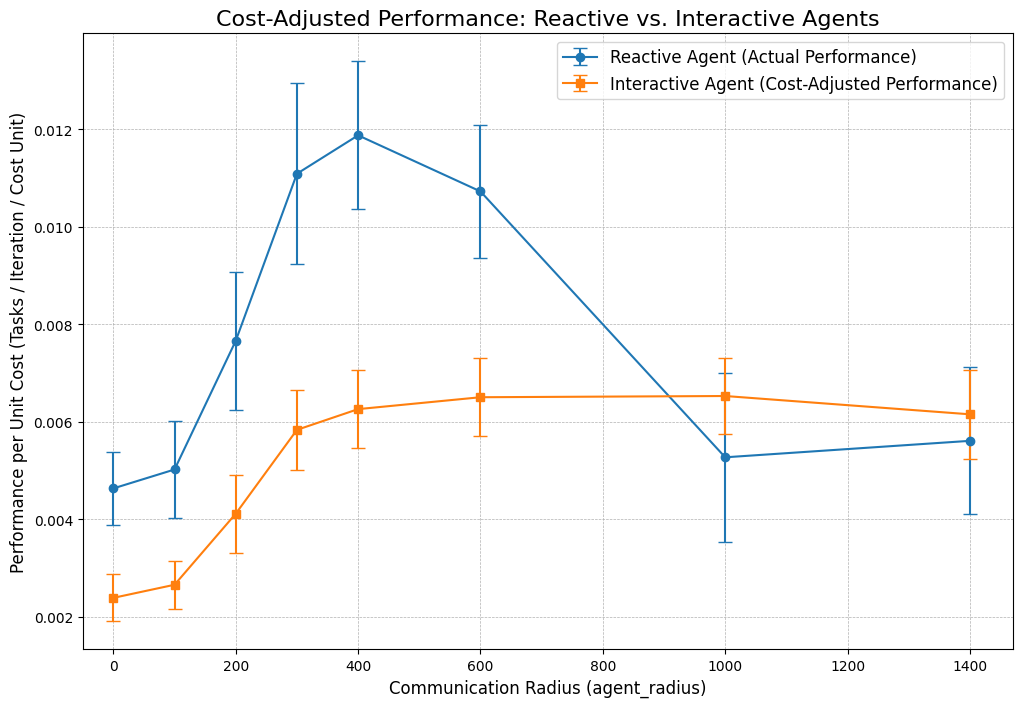

In [ ]:
REPLICATIONS = 20
ITERATIONS = 4000

# --- Define Base Parameters for Both Agent Types ---
base_params = {
    'ENV_SIZE': (1000, 1000),
    'task_count': 2,
    'task_capacity': 3,
    'task_radius': 50,
    'agent_count': 30,
    'velocity': 25,
    'timeout_callout': 200,
    'timeout_respond': 250,
    'iterations': ITERATIONS
}

# --- Define the Parameter Sweep ---
# We will test performance vs. communication distance (agent_radius)
sweep_parameters = {
    'agent_radius': [0, 100, 200, 300, 400, 600, 1000, 1400],
}

# --- Agent Initializer Functions ---
def socialAgentInit(pos, velocity, params):
    return SocialAgent(
        pos, params['ENV_SIZE'], params['task_radius'], params['agent_radius'],
        params['timeout_callout'], params['timeout_respond'], velocity
    )

def auctionAgentInit(pos, velocity, params):
    return SimpleAuctionAgent(
        pos, params['ENV_SIZE'], params['task_radius'], params['agent_radius'],
        params['timeout_callout'], params['timeout_respond'], velocity
    )

# --- Run Simulation for Social (Reactive) Agent ---
social_runner = SimulationRunner(Environment, socialAgentInit, base_params)
social_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=REPLICATIONS,
    description="Reactive Agent (Social)"
)
social_results_df = social_runner.results

# --- Run Simulation for Auction (Interactive) Agent ---
auction_runner = SimulationRunner(Environment, auctionAgentInit, base_params)
auction_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=REPLICATIONS,
    description="Interactive Agent (Auction)"
)
auction_results_df = auction_runner.results

# =============================================================================
# SECTION 3: DATA PROCESSING AND PLOTTING
# =============================================================================

print("\n--- Generating Final Plot ---")

# --- Process Social Agent Results ---
social_stats = social_results_df.groupby('agent_radius')['score'].agg(['mean', 'std']).reset_index()
social_stats.rename(columns={'mean': 'mean_score', 'std': 'std_dev'}, inplace=True)

# --- Process Auction Agent Results and Apply Cost Adjustment ---
auction_stats = auction_results_df.groupby('agent_radius')['score'].agg(['mean', 'std']).reset_index()
auction_stats.rename(columns={'mean': 'mean_score', 'std': 'std_dev'}, inplace=True)
# This is the key step: divide performance by 2 to account for doubled cost
auction_stats['cost_adjusted_score'] = auction_stats['mean_score'] / 2.0
auction_stats['cost_adjusted_std'] = auction_stats['std_dev'] / 2.0


plt.figure(figsize=(12, 8))

# Plot Reactive Agent performance
plt.errorbar(social_stats['agent_radius'], social_stats['mean_score'], yerr=social_stats['std_dev'],
             fmt='-o', capsize=5, label='SA score')

# Plot Interactive Agent cost-adjusted performance
plt.errorbar(auction_stats['agent_radius'], auction_stats['cost_adjusted_score'], yerr=auction_stats['cost_adjusted_std'],
             fmt='-s', capsize=5, label='AA score')

# --- Formatting ---
plt.title('Comparison of Performance Between SA and AA', fontsize=16)
plt.xlabel('Communication Radius (agent_radius)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(left=-50) # Adjust x-axis to start just before 0
plt.show()